# Assignment 4: Geospatial Mapping and Field Variability Visualization

## 1. Geospatial Data Preparation

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Load Data
# Field Boundaries
fields_gdf = gpd.read_file('../data/assignment-02/fields_with_crops.geojson')

# Soil Data (CSV -> merged to GDF)
soil_df = pd.read_csv('../data/assignment-02/soil_EPSG4326.csv')

# Check CRS
print(f"Original Fields CRS: {fields_gdf.crs}")

# Join Data
# Ensure CRS is EPSG:4326
field_soil_gdf = fields_gdf.merge(soil_df, on='field_id', how='left')
field_soil_gdf = field_soil_gdf.to_crs(epsg=4326)

print(f"Final Joined CRS: {field_soil_gdf.crs}")
print(f"Loaded {len(field_soil_gdf)} field polygons with soil data.")


Original Fields CRS: EPSG:4326
Final Joined CRS: EPSG:4326
Loaded 30 field polygons with soil data.


## 2. Map Construction (The "2 Layer" Task)

Plotting the base boundary layer and overlaying the soil type choropleth.

High-quality map saved to: output/dashboard_assets/field_spatial_map.png


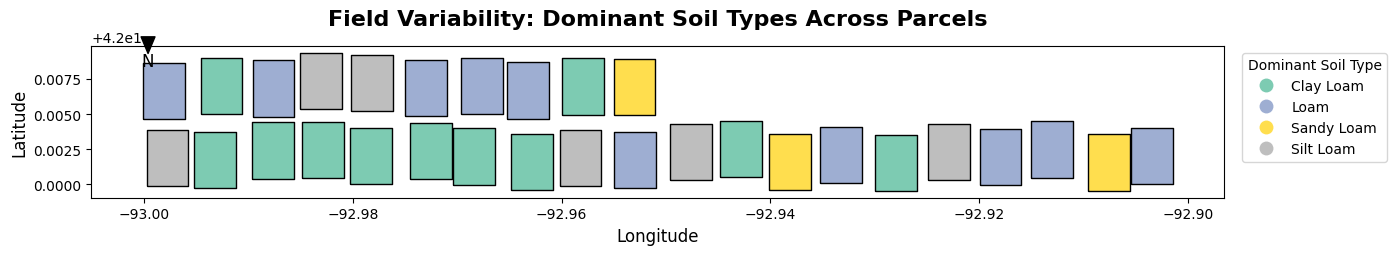

In [2]:
import os

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Layer 1: Base outline of the field boundaries
field_soil_gdf.boundary.plot(ax=ax, color='black', linewidth=1, zorder=2)

# Layer 2: Overlay coloring by Dominant Soil Type
# Using a qualitative colormap for categorical data (soil types)
field_soil_gdf.plot(column='dominant_soil',
                    categorical=True, 
                    legend=True, 
                    cmap='Set2', 
                    ax=ax, 
                    alpha=0.85,
                    zorder=1,
                    legend_kwds={'title': 'Dominant Soil Type', 'loc': 'upper right', 'bbox_to_anchor': (1.15, 1)})

# Map Elements: Title & Labels
plt.title('Field Variability: Dominant Soil Types Across Parcels', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Optional: Add a simple North Arrow
x, y, arrow_length = 0.05, 0.95, 0.05
ax.annotate('N', xy=(x, y), xytext=(x, y-arrow_length),
            arrowprops=dict(facecolor='black', width=3, headwidth=10),
            ha='center', va='center', fontsize=12,
            xycoords=ax.transAxes)

plt.tight_layout()

# Save for Dashboard Export
os.makedirs('../output/dashboard_assets', exist_ok=True)
plt.savefig('../output/dashboard_assets/field_spatial_map.png', dpi=300, bbox_inches='tight')
print("High-quality map saved to: output/dashboard_assets/field_spatial_map.png")
plt.show()

## Interpretation

The map reveals the spatial distribution and clustering of soil types across the agricultural portfolio. Fields in close proximity often share the same dominant soil type, such as the large clusters of Loam and Silt Loam forming contiguous bands. This geographic clustering suggests that underlying topographical and geological formations dictate the soil composition across broad areas, which farm managers can use to create unified management zones across adjacent fields rather than treating each boundary uniquely.